# Monte Carlo Simulation for Trading Scenarios
This notebook performs a Monte Carlo simulation to analyze potential trading outcomes based on user-defined parameters.

## Define Input Variables
Define variables such as initial balance, risk percentage per trade, winning trade percentage, break-even trade percentage, average number of trades per month, total months, and take profit/stop loss ratio.

In [37]:
# Define Input Variables
initial_balance = 3000  # Starting balance in dollars
risk_per_trade = 0.005  # Risk percentage per trade (e.g., 0.5%)
winning_trade_percentage = 55  # Percentage of winning trades
break_even_trade_percentage = 5  # Percentage of break-even trades
avg_trades_per_month = 30  # Average number of trades per month
total_months = 48  # Total number of months for the simulation
tp_sl_ratio = 1.0  # Take profit/Stop loss ratio

## Simulate Trades
Simulate individual trades based on the input variables using random number generation to determine wins, losses, and break-even outcomes.

In [38]:
import random

def simulate_trade():
    """Simulate the outcome of a single trade."""
    outcome = random.uniform(0, 100)
    if outcome < winning_trade_percentage:
        return tp_sl_ratio  # Win
    elif outcome < winning_trade_percentage + break_even_trade_percentage:
        return 0  # Break-even
    else:
        return -1  # Loss

## Run Monte Carlo Simulations
Run multiple simulations of the trading scenario over the specified time period and store the results for each simulation.

In [39]:
def run_simulation():
    """Run a single Monte Carlo simulation."""
    balance = initial_balance
    monthly_balances = []
    for _ in range(total_months):
        monthly_result = 0
        for _ in range(avg_trades_per_month):
            trade_result = simulate_trade()
            monthly_result += balance * risk_per_trade * trade_result
        balance += monthly_result
        monthly_balances.append(balance)
    return monthly_balances

# Run multiple simulations
num_simulations = 1000
all_simulations = [run_simulation() for _ in range(num_simulations)]

## Plot Monte Carlo Simulation Results
Generate a plot showing the results of all Monte Carlo simulations, including the range of possible outcomes.

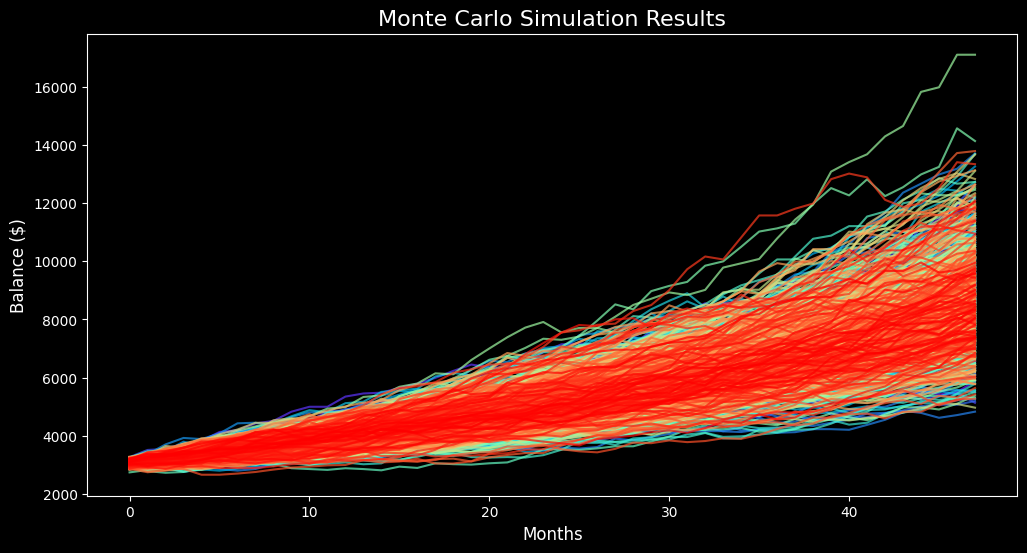

In [40]:
# Plot all simulations with a black background and vibrant colors
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Set the black background
plt.style.use('dark_background')

# Create the plot
plt.figure(figsize=(12, 6))

# Generate vibrant colors for the lines
colors = cm.rainbow(np.linspace(0, 1, len(all_simulations)))

# Plot each simulation with a vibrant color
for simulation, color in zip(all_simulations, colors):
    plt.plot(simulation, color=color, alpha=0.7)

# Add titles and labels
plt.title('Monte Carlo Simulation Results', fontsize=16, color='white')
plt.xlabel('Months', fontsize=12, color='white')
plt.ylabel('Balance ($)', fontsize=12, color='white')

# Show the plot
plt.show()

## Calculate Statistics (Most Possible, Worst, Best)
Calculate and display statistics such as initial balance, final balance, return percentage, maximum drawdown, maximum consecutive losses, maximum consecutive wins, and win percentage for the most possible, worst, and best scenarios.

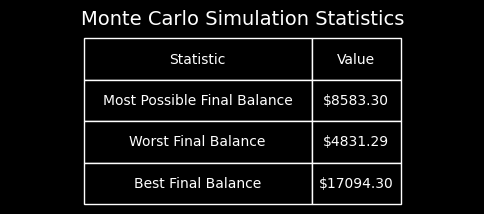

In [41]:
# Visualize Statistics in a Table with Proper Title Placement
import matplotlib.pyplot as plt

def plot_statistics_table(statistics):
    """
    Plots the statistics (most possible, worst, and best final balances) in a table chart.
    
    Parameters:
        statistics (dict): Dictionary containing the statistics to display.
    """
    # Prepare data for the table
    data = [
        ["Most Possible Final Balance", f"${statistics['most_possible']:.2f}"],
        ["Worst Final Balance", f"${statistics['worst']:.2f}"],
        ["Best Final Balance", f"${statistics['best']:.2f}"]
    ]
    
    # Create the figure and axis
    fig, ax = plt.subplots(figsize=(6, 2))
    ax.axis('tight')
    ax.axis('off')
    
    # Create the table
    table = ax.table(cellText=data, colLabels=["Statistic", "Value"], loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)  # Shrink the font size for better spacing
    table.auto_set_column_width([0, 1])  # Adjust column widths
    
    # Add padding to cells for better spacing
    for key, cell in table.get_celld().items():
        cell.set_edgecolor('white')  # Set cell border color
        cell.set_text_props(color='white')  # Set text color
        cell.set_facecolor('black')  # Set cell background color
        cell.set_height(0.3)  # Increase cell height for spacing
    
    # Add a title with proper spacing
    plt.subplots_adjust(top=0.8)  # Adjust the top margin to make space for the title
    plt.title("Monte Carlo Simulation Statistics", fontsize=14, color='white', pad=20)  # Add padding to the title
    
    # Show the table
    plt.show()

# Example: Calculate statistics and plot the table
statistics = calculate_statistics(all_simulations)
plot_statistics_table(statistics)

## Generate Monthly Statistics
Calculate and display monthly statistics for each simulation, including percentage returns and dollar returns.

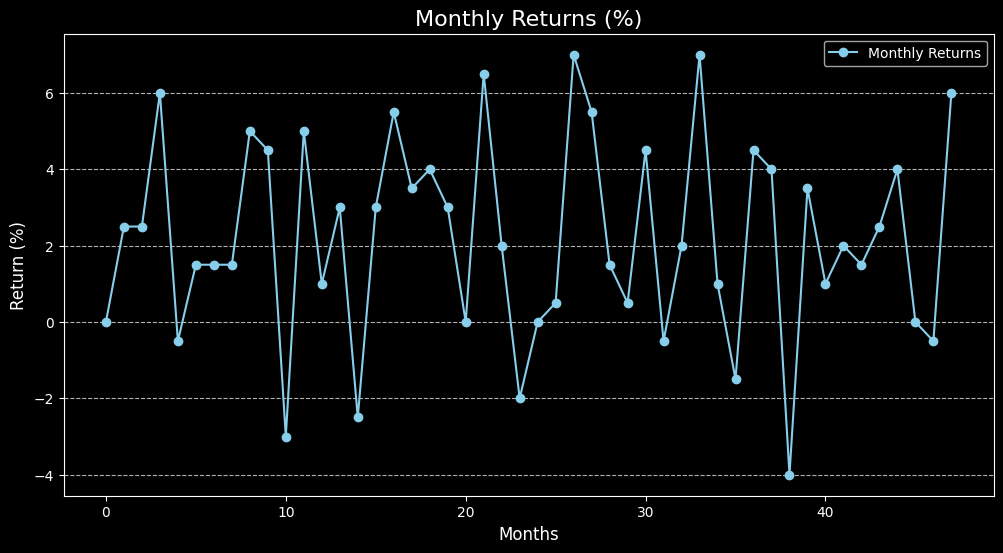

In [42]:
# Visualize Monthly Returns with a Line Chart
import matplotlib.pyplot as plt

def plot_monthly_returns_line_chart(monthly_returns):
    """
    Plots the monthly returns as a line chart.
    
    Parameters:
        monthly_returns (list): List of monthly returns in percentage.
    """
    plt.figure(figsize=(12, 6))
    plt.plot(monthly_returns, marker='o', linestyle='-', color='skyblue', label='Monthly Returns')
    plt.title('Monthly Returns (%)', fontsize=16)
    plt.xlabel('Months', fontsize=12)
    plt.ylabel('Return (%)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()

# Example: Calculate and plot monthly statistics for the first simulation
monthly_statistics = calculate_monthly_statistics(all_simulations[0])
plot_monthly_returns_line_chart(monthly_statistics)